In [1]:
import matplotlib.pyplot as plt
import numpy as np

import torch
from torch import nn, optim
from torchvision import datasets, transforms

import zipfile

import shutil
import os
import pandas as pd

device = ("cuda" if torch.cuda.is_available() else "cpu") # Use GPU or CPU for training

In [2]:
'''with zipfile.ZipFile("celeba.zip","r") as zip_ref:
  zip_ref.extractall("data_faces/")'''

'with zipfile.ZipFile("celeba.zip","r") as zip_ref:\n  zip_ref.extractall("data_faces/")'

In [3]:

root = 'data_faces/img_align_celeba'
img_list = os.listdir(root)
print(len(img_list))
     

202599


In [7]:

df = pd.read_csv("list_attr_celeba.csv")
#df = df[['image_id', 'Smiling']]

In [10]:
df
#get all the row titles
df.index
# get all the column titles
df.columns

Index(['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive',
       'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose',
       'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows',
       'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair',
       'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open',
       'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin',
       'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns',
       'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings',
       'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace',
       'Wearing_Necktie', 'Young'],
      dtype='object')

In [5]:
# to make directories

'''!rm -rf data
!mkdir data && mkdir data/smile && mkdir data/no_smile'''

'!rm -rf data\n!mkdir data && mkdir data/smile && mkdir data/no_smile'

In [6]:
'''
s0 = 0
s1 = 0

num = 70000

for i, (_, i_row) in enumerate(df.iterrows()):
  if s0 < num:
    if i_row['Smiling'] == 1:
      s0 += 1
      shutil.copyfile('data_faces/img_align_celeba/' + i_row['image_id'], 'data_cel/smile/' + i_row['image_id'])
  
  if s1 < num:
    if i_row['Smiling'] == -1:
      s1 += 1
      shutil.copyfile('data_faces/img_align_celeba/' + i_row['image_id'], 'data_cel/no_smile/' + i_row['image_id'])
  
  if s0 == num and s1 == num:
    break'''

"\ns0 = 0\ns1 = 0\n\nnum = 70000\n\nfor i, (_, i_row) in enumerate(df.iterrows()):\n  if s0 < num:\n    if i_row['Smiling'] == 1:\n      s0 += 1\n      shutil.copyfile('data_faces/img_align_celeba/' + i_row['image_id'], 'data_cel/smile/' + i_row['image_id'])\n  \n  if s1 < num:\n    if i_row['Smiling'] == -1:\n      s1 += 1\n      shutil.copyfile('data_faces/img_align_celeba/' + i_row['image_id'], 'data_cel/no_smile/' + i_row['image_id'])\n  \n  if s0 == num and s1 == num:\n    break"

In [7]:

img_list = os.listdir('data_cel/smile/')
img_list.extend(os.listdir('data_cel/no_smile/'))

In [8]:
print("Images: ", len(img_list))


Images:  140000


In [9]:
transform = transforms.Compose([
          transforms.Resize((64, 64)),
          transforms.ToTensor()
          ])

batch_size = 64
celeba_data = datasets.ImageFolder('data_cel', transform=transform)

In [10]:
print(celeba_data.classes)
print(len(celeba_data))

['no_smile', 'smile']
140000


In [11]:

train_set, test_set = torch.utils.data.random_split(celeba_data, [int(len(img_list) * 0.75), len(img_list) - int(len(img_list) * 0.75)])
train_data_size = len(train_set)
test_data_size = len(test_set)

In [12]:
trainLoader = torch.utils.data.DataLoader(train_set,batch_size=batch_size, shuffle=True)
testLoader  = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=True)

In [13]:


print(train_data_size)
print(test_data_size)

105000
35000


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from vae import VAE, VAE_big, VAE_big_layered

In [15]:
image_channels = 3

print('image_channels', image_channels)

#model = VAE(image_channels=image_channels).to(device)

model = VAE_big_layered(image_channels=image_channels).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4) 

image_channels 3


In [16]:
def loss_fn(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x, size_average=False)
    KLD = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KLD, BCE, KLD

In [17]:
epochs = 200


In [18]:
train_loss = []

for epoch in range(epochs):
   
    total_train_loss = 0
    # training our model
    for idx, (image, label) in enumerate(trainLoader):
        images, label = image.to(device), label.to(device)

        recon_images, mu, logvar = model(images.to(device))
        loss, bce, kld = loss_fn(recon_images.to(device), images.to(device), mu.to(device), logvar.to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


    print('loss', loss)
    print("Epoch : ", epoch)


torch.save(model.state_dict(), '/home/luser/autoencoder_attacks/saved_celebA/celebA_CNN_VAE_big_layered_trainSize'+str(train_data_size)+'_epochs'+str(epochs)+'.torch')

/home/luser/anaconda3/envs/inn/lib/python3.9/site-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))


loss tensor(259125.3438, device='cuda:0', grad_fn=<AddBackward0>)
Epoch :  0
loss tensor(250966.7344, device='cuda:0', grad_fn=<AddBackward0>)
Epoch :  1
loss tensor(252196.3125, device='cuda:0', grad_fn=<AddBackward0>)
Epoch :  2
loss tensor(245273.2500, device='cuda:0', grad_fn=<AddBackward0>)
Epoch :  3
loss tensor(243416.2500, device='cuda:0', grad_fn=<AddBackward0>)
Epoch :  4
loss tensor(254816.4062, device='cuda:0', grad_fn=<AddBackward0>)
Epoch :  5
loss tensor(250132.9219, device='cuda:0', grad_fn=<AddBackward0>)
Epoch :  6
loss tensor(248107.5156, device='cuda:0', grad_fn=<AddBackward0>)
Epoch :  7
loss tensor(252854.7500, device='cuda:0', grad_fn=<AddBackward0>)
Epoch :  8
loss tensor(244438.7188, device='cuda:0', grad_fn=<AddBackward0>)
Epoch :  9
loss tensor(229769.3438, device='cuda:0', grad_fn=<AddBackward0>)
Epoch :  10
loss tensor(240130.6562, device='cuda:0', grad_fn=<AddBackward0>)
Epoch :  11
loss tensor(234606.2500, device='cuda:0', grad_fn=<AddBackward0>)
Epoch : 

In [19]:
model = VAE_big_layered(image_channels=image_channels).to(device)


In [20]:
model.load_state_dict(torch.load('/home/luser/autoencoder_attacks/saved_celebA/celebA_CNN_VAE_big_layered_trainSize'+str(train_data_size)+'_epochs'+str(epochs)+'.torch'))

# Set the model to evaluation mode (if needed)
model.eval()

VAE_big_layered(
  (encoder_6): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2))
    (1): ReLU()
  )
  (encoder_5): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (encoder_4): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (encoder_3): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (encoder_2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2))
    (1): ReLU()
  )
  (encoder_1): Sequential(
    (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2))
    (1): ReLU()
  )
  (encoder_0): Sequential(
    (0): Conv2d(256, 256, kernel_size=(4, 4), stride=(2, 2))
    (1): ReLU()
    (2): Flatten()
  )
  (fc1): Linear(in_features=1024, out_features=256, bias=True)
  (fc2): Linear(in_features=1024, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_feature

In [21]:
for idx, (image, label) in enumerate(trainLoader):
    images, label = image.to(device), label.to(device)
    break

In [22]:
recon_images, mu, logvar = model(images.to(device))


In [23]:
recon_images.shape

torch.Size([64, 3, 64, 64])

In [24]:
selected_ind = 7

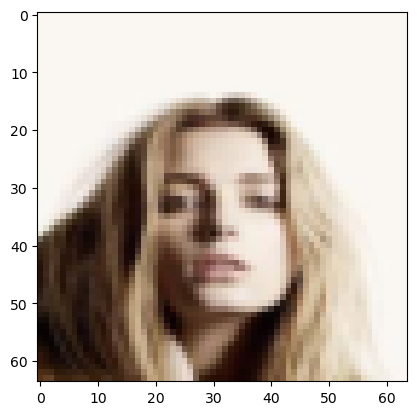

In [25]:
plt.imshow(images[selected_ind].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')


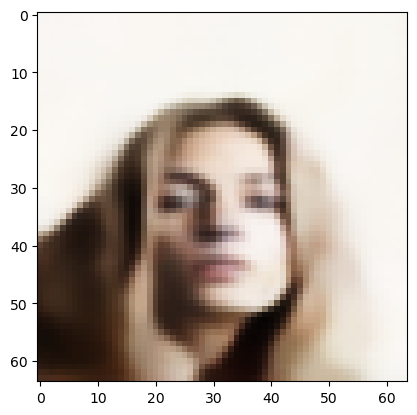

In [26]:
plt.imshow(recon_images[selected_ind].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')
